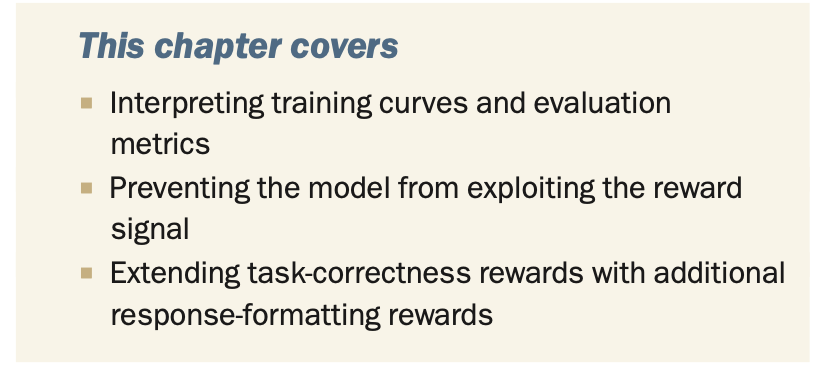


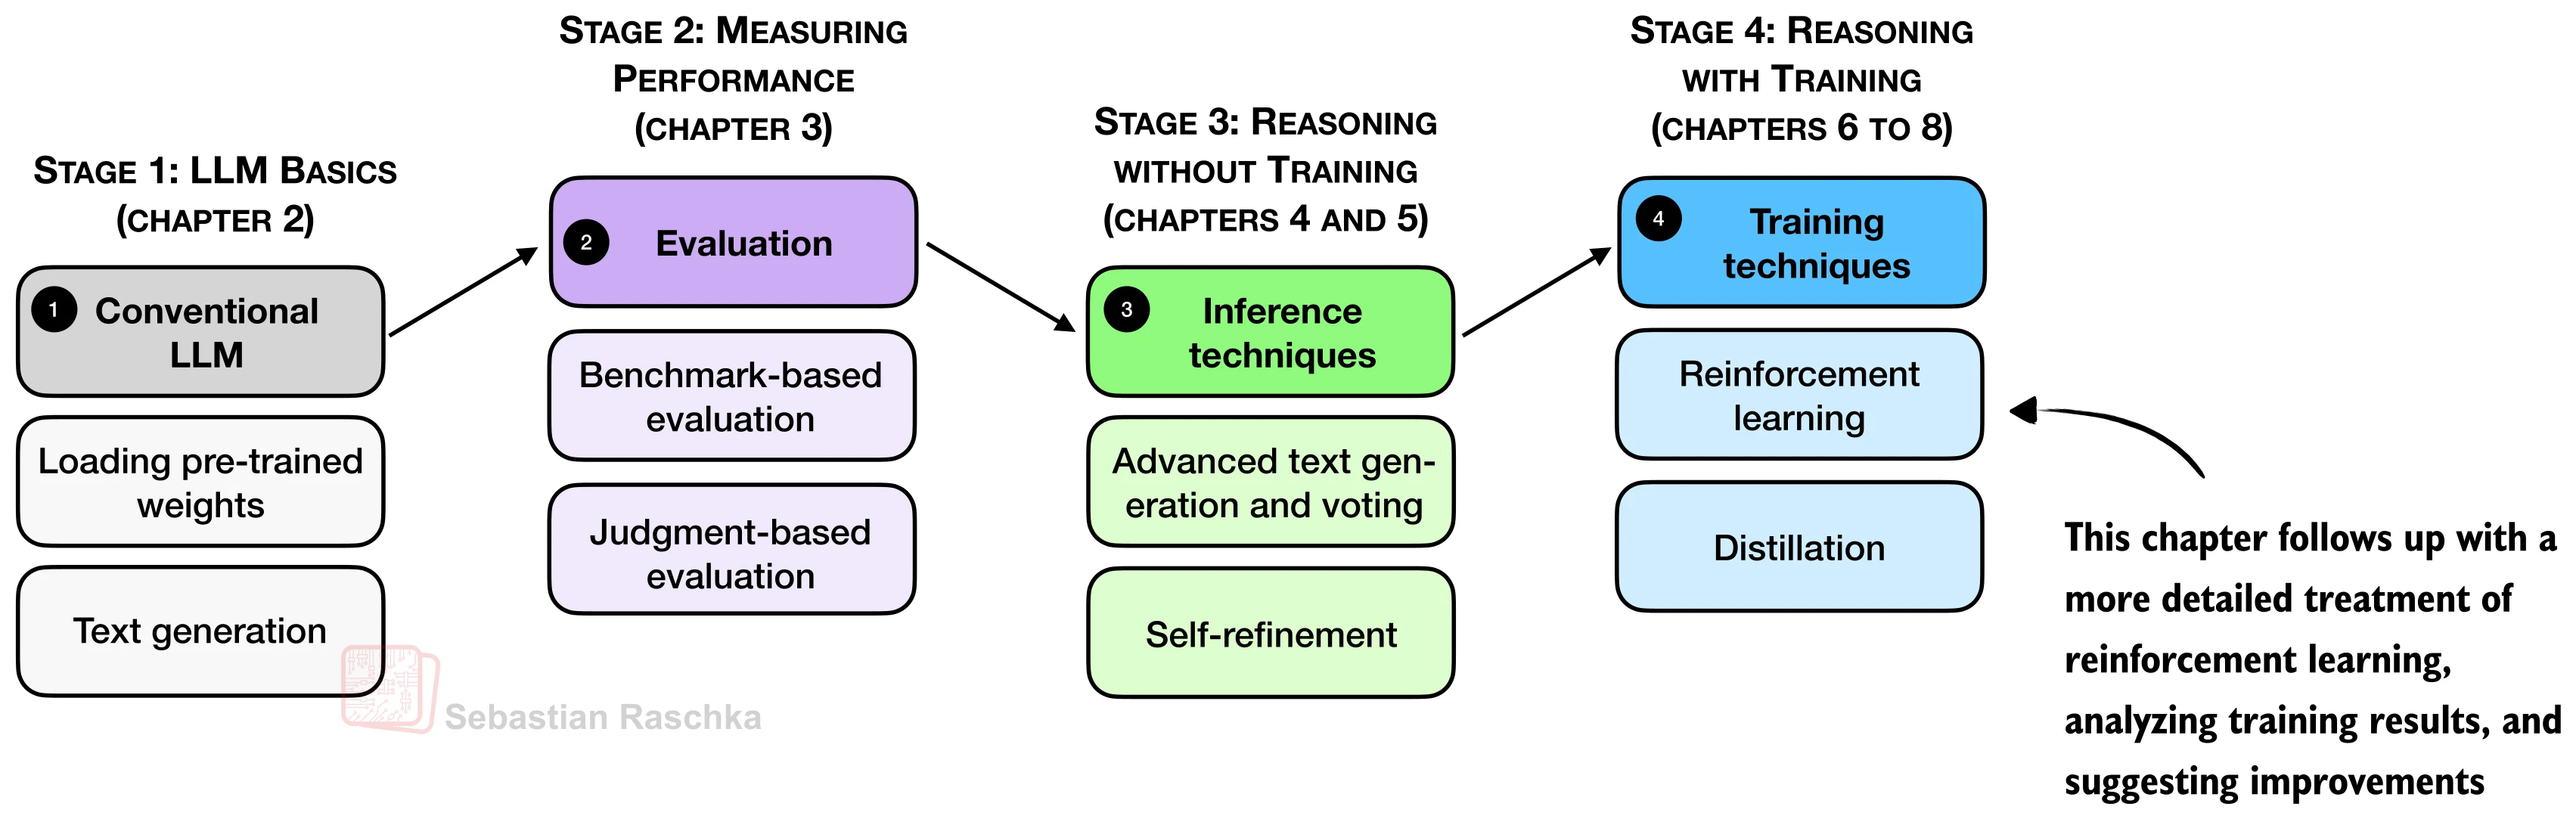


# 7.1 Improving GRPO

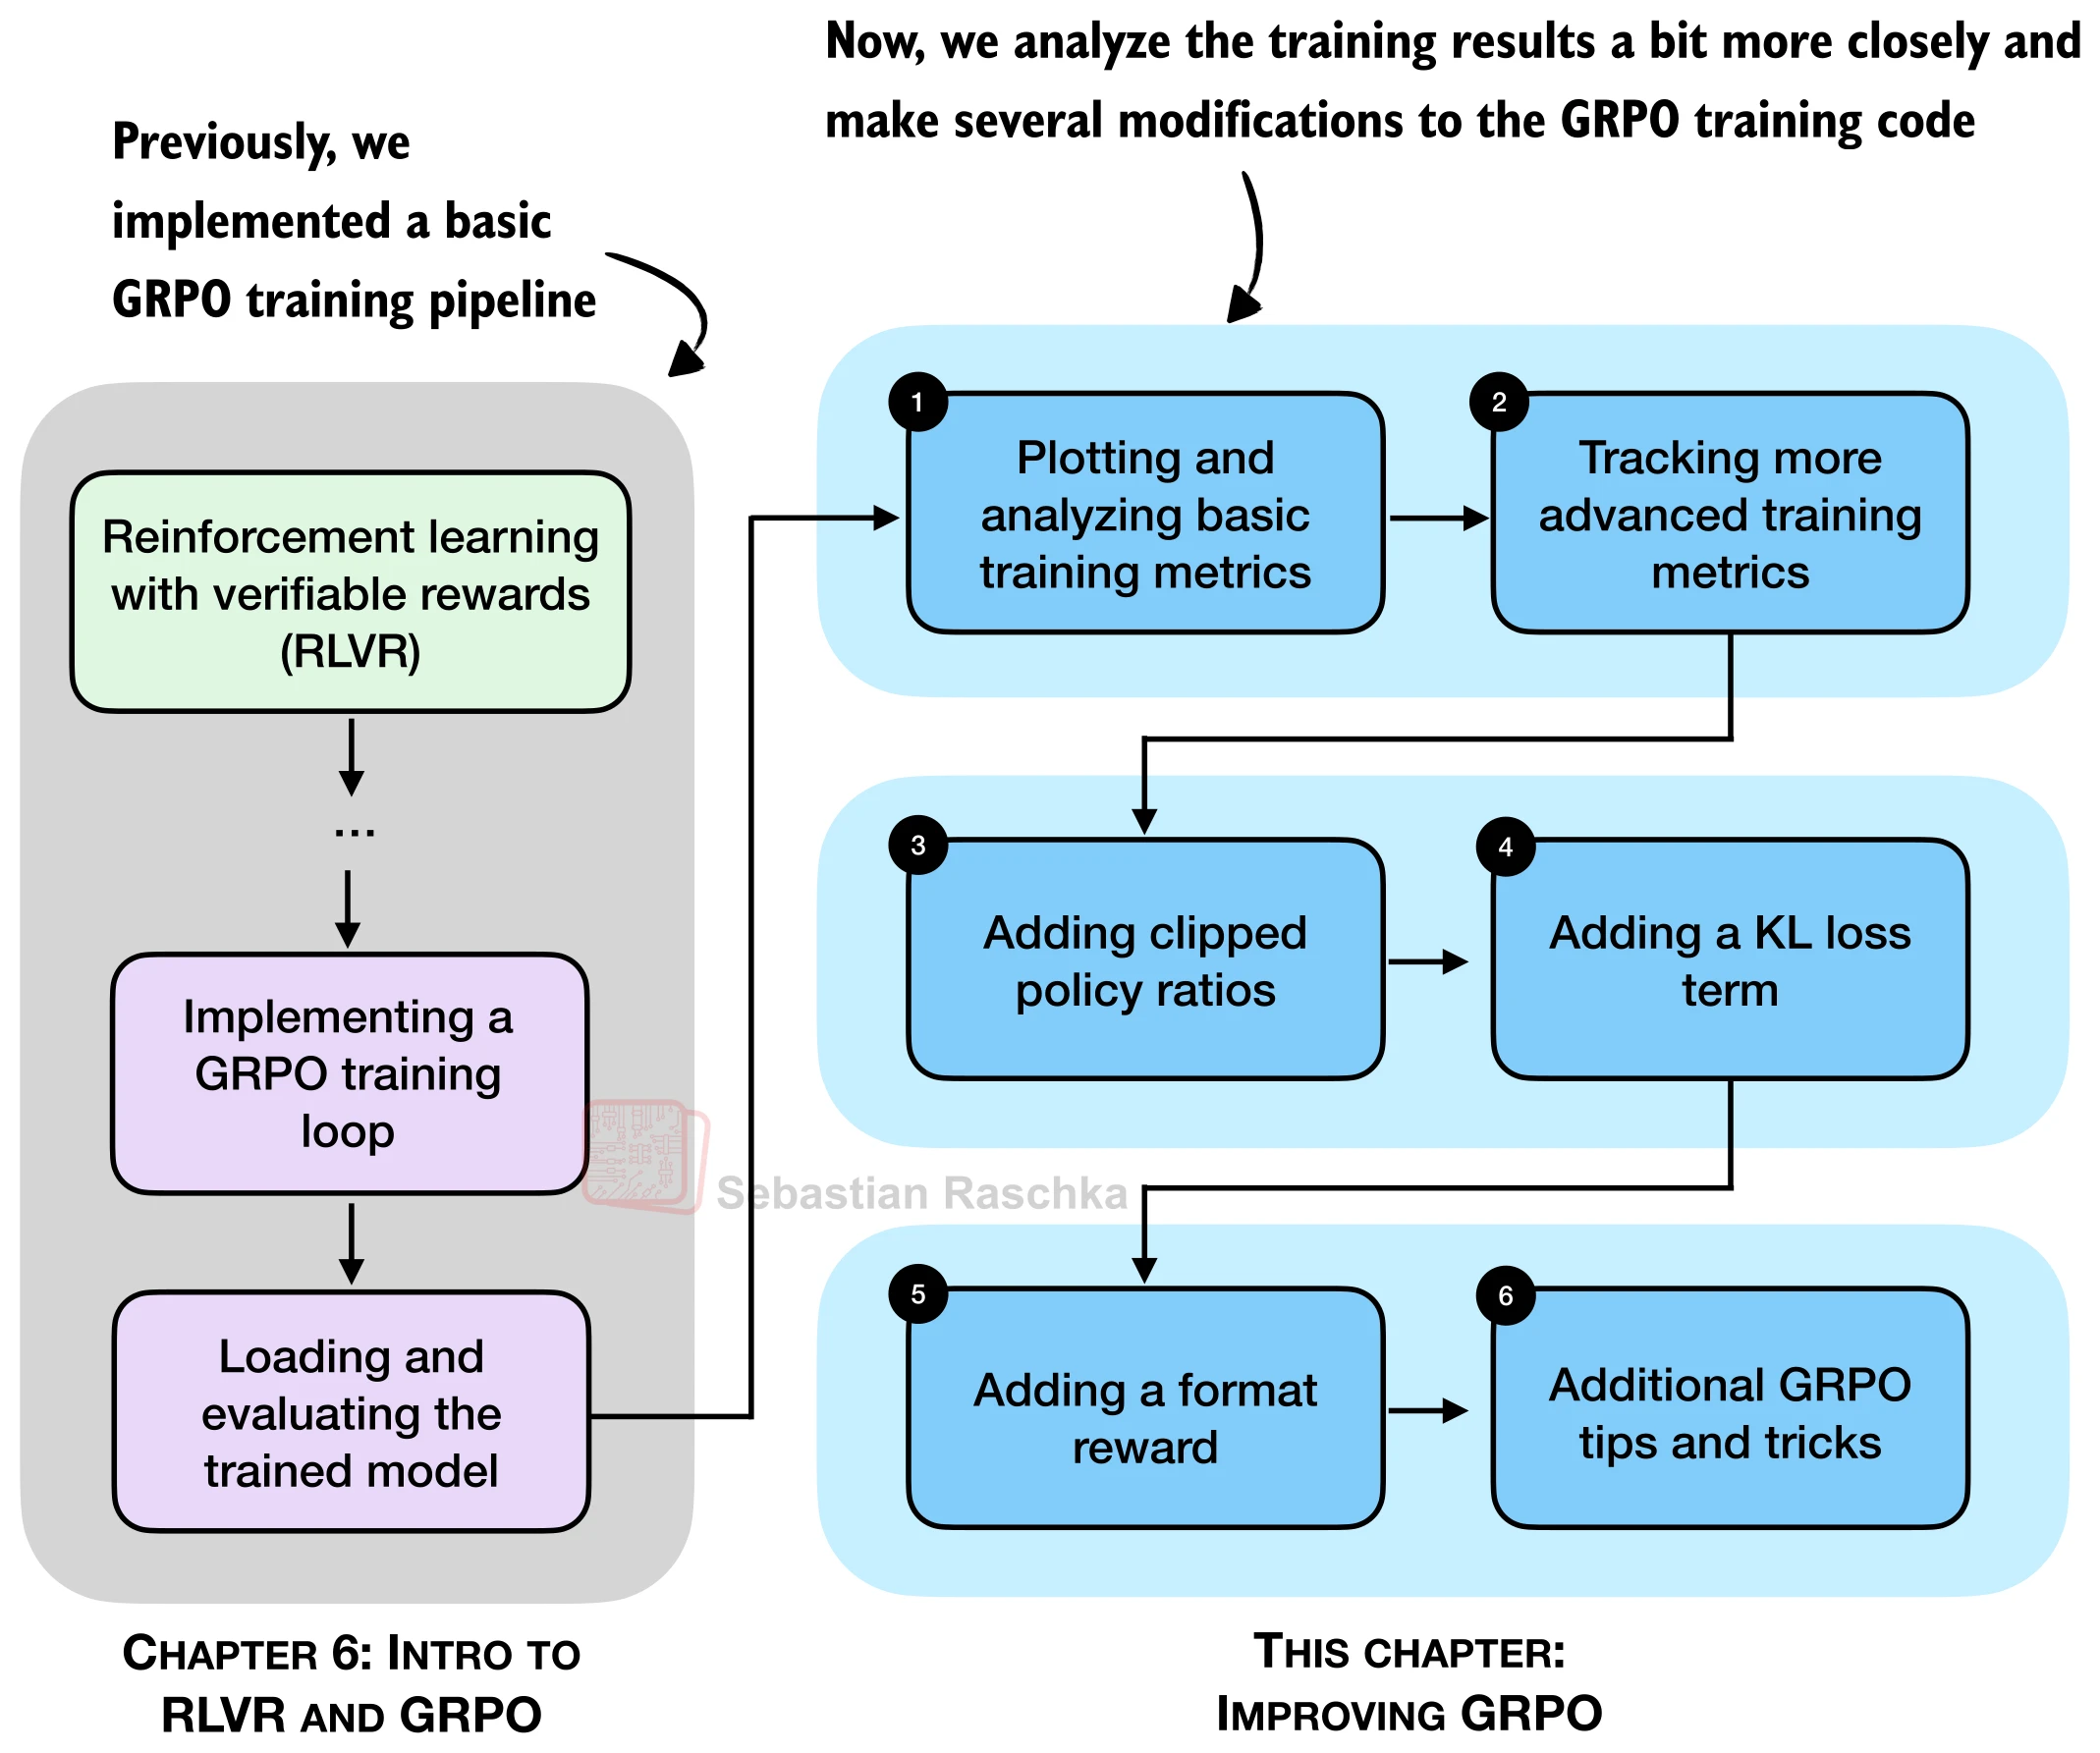


In [5]:
from pathlib import Path
import requests


def download_from_github(rel_path, out=None):
    github_raw_base = (  # Base URL
        "https://raw.githubusercontent.com/rasbt/"
        "reasoning-from-scratch/refs/heads/main/"
    )

    rel_path = Path(rel_path)
    # Use URL file name as default output file name
    out = Path(out) if out is not None else Path(rel_path.name)

    # Skip download if file already exists locally
    if out.exists():
        size_kb = out.stat().st_size / 1e3
        print(f"{out}: {size_kb:.1f} KB (cached)")
        return out

    # Download file
    r = requests.get(github_raw_base + rel_path.as_posix())
    r.raise_for_status()

    out.write_bytes(r.content)
    size_kb = out.stat().st_size / 1e3
    print(f"{out}: {size_kb:.1f} KB")

In [6]:
# Download GRPO script (based on code from chapter 6):
download_from_github("ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py")

rlvr_grpo_original_no_kl.py: 15.6 KB (cached)


PosixPath('rlvr_grpo_original_no_kl.py')

In [7]:
# !uv run rlvr_grpo_original_no_kl.py \
#     --steps 500  \
#     --max_new_tokens 1024

In [8]:
# Log file in plain text

download_from_github("ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.txt")

# Same log file in CSV format
download_from_github("ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.csv")

ch06_rlvr_grpo_original_no_kl_metrics.txt: 43.7 KB
ch06_rlvr_grpo_original_no_kl_metrics.csv: 25.1 KB


# 7.2.2 Inspecting the GRPO training run

- We use the following utility functions to plot the results from the log files throughout this chapter


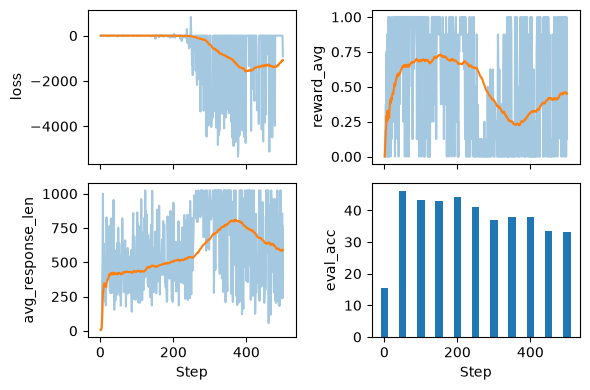

In [9]:
import csv
import matplotlib.pyplot as plt


def moving_average(values, window_fraction=0.25):
    # Smooth a noisy training signal to reveal longer-term trends during training
    window_size = max(1, int(window_fraction * len(values)))
    smoothed = []

    for i in range(len(values)):
        start_idx = max(0, i - window_size + 1)
        window_mean = sum(values[start_idx : i + 1]) / (i - start_idx + 1)
        smoothed.append(window_mean)

    return smoothed


def plot_grpo_metrics(csv_path, columns, save_as=None):
    data = {name: {"steps": [], "values": []} for name in columns}

    # Open and read CSV log file
    with Path(csv_path).open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row or not row.get("step"):
                continue

            # Use the training step as the shared x-axis across all metrics
            step = int(row["step"])

            for name in columns:
                value_str = row.get(name)
                if value_str:
                    data[name]["steps"].append(step)
                    data[name]["values"].append(float(value_str))

    # Create a fixed grid so loss, rewards, response length, etc. can be shown side by side
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(6, 4))
    axes = axes.ravel()

    for i, name in enumerate(columns):
        steps = data[name]["steps"]
        values = data[name]["values"]

        # Skip metrics that are not present
        if not values:
            fig.delaxes(axes[i])
            continue

        # Evaluation accuracy as barplot because we don't have data for each step
        if name == "eval_acc":
            axes[i].bar(steps, values, width=20)
        else:
            axes[i].plot(steps, values, alpha=0.4)
            axes[i].plot(steps, moving_average(values))

        axes[i].set_ylabel(name)

    for j in (2, 3):
        if axes[j] in fig.axes:
            axes[j].set_xlabel("Step")

    plt.tight_layout()
    if save_as is not None:
        plt.savefig(save_as)
    plt.show()


# Plot the GRPO training run
plot_grpo_metrics(
    "ch06_rlvr_grpo_original_no_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    # save_as="4.pdf"
)

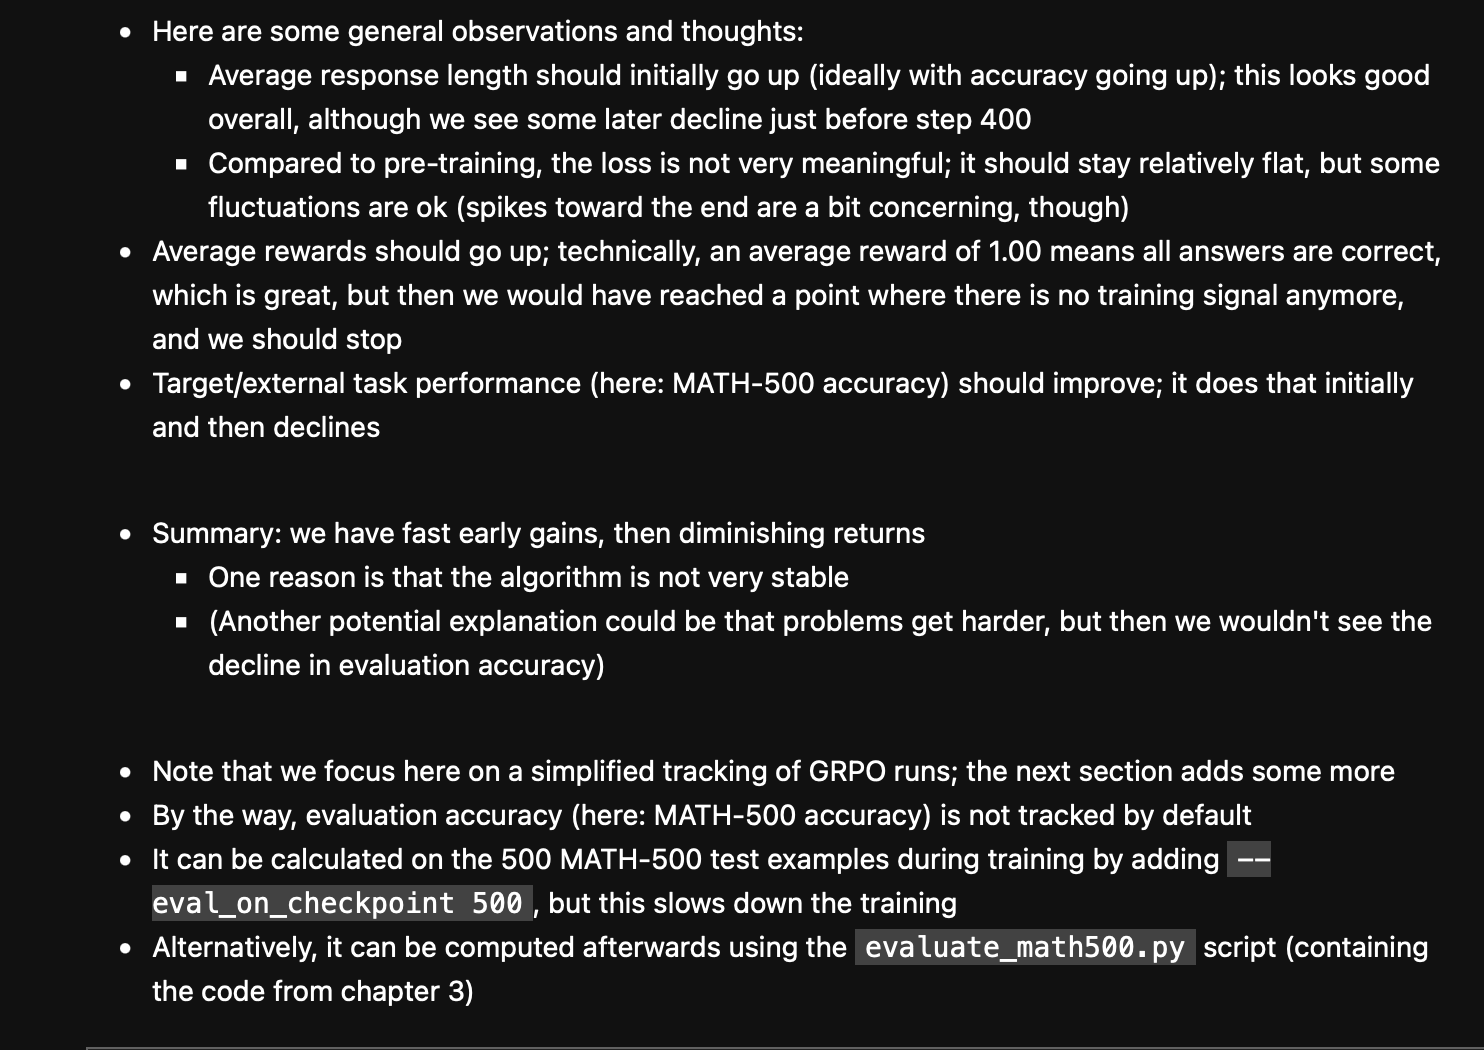


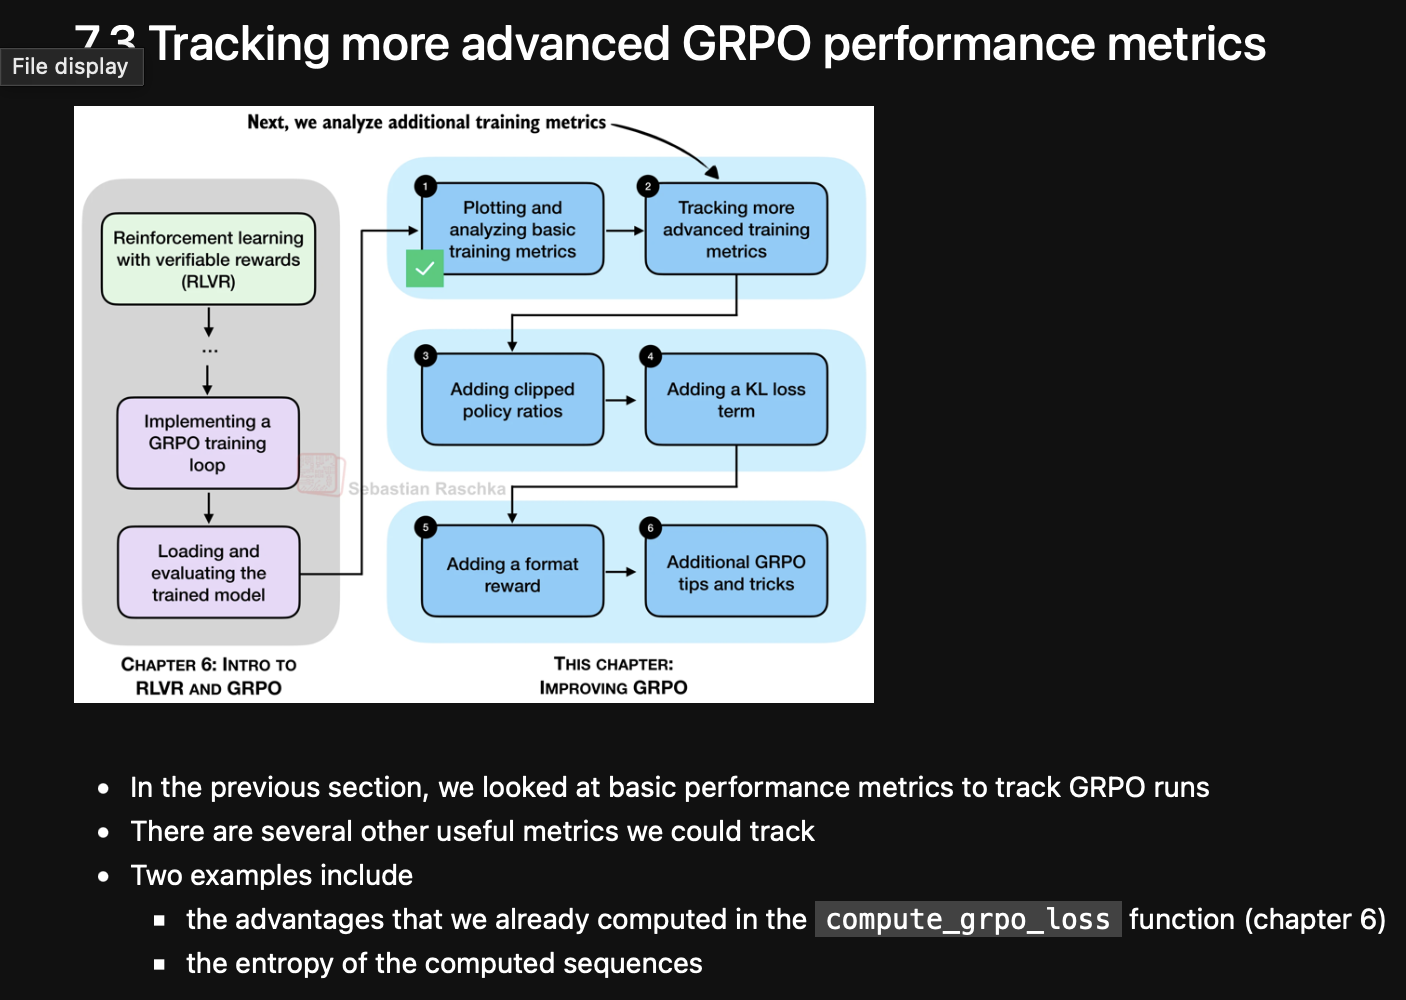


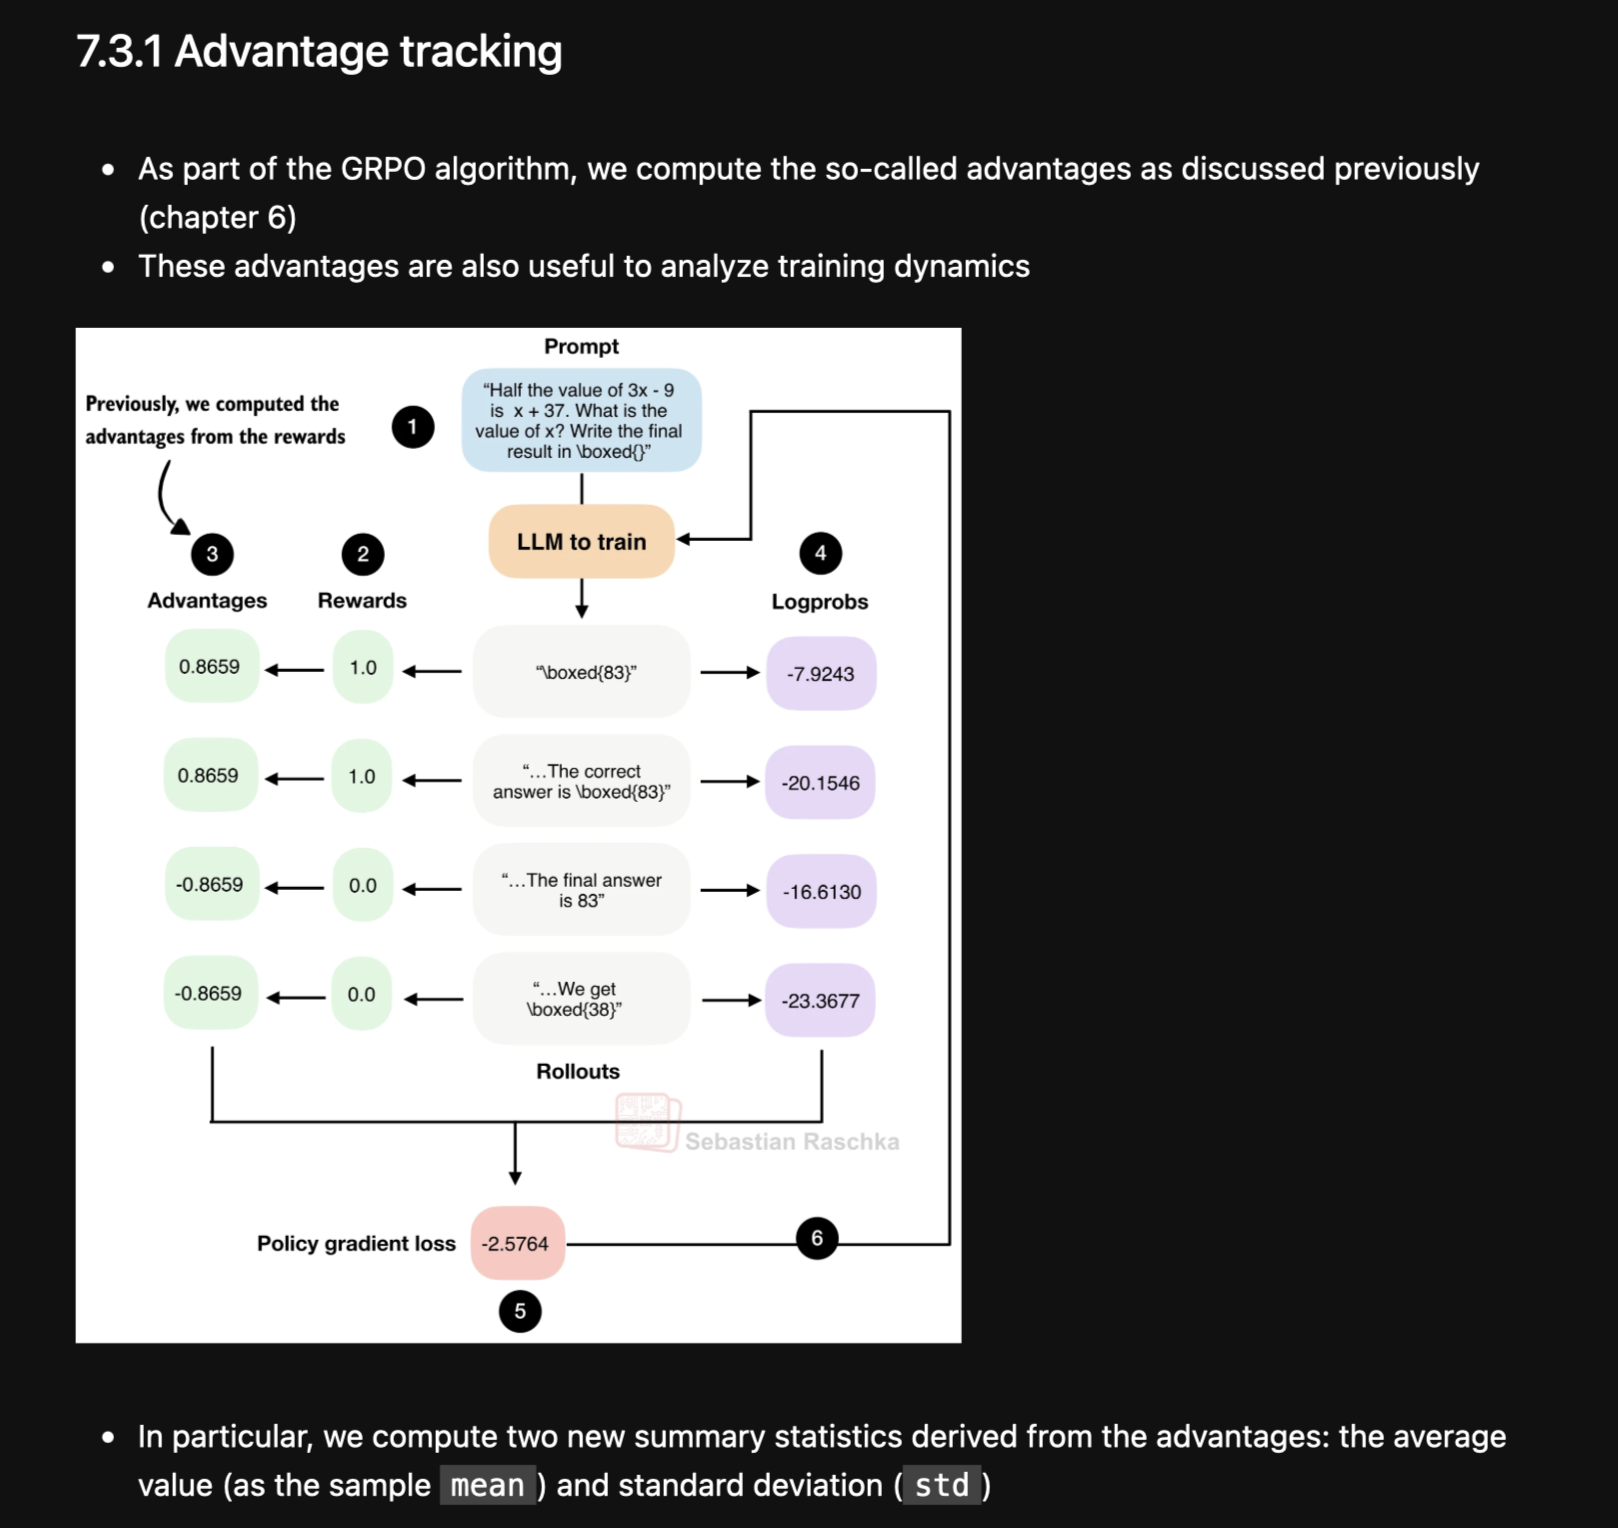


In [10]:
import torch


def compute_advantage_stats(rewards_list):
    # This is what we already compute in GRPO:
    rewards = torch.tensor(rewards_list)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    # These are the new statistics we add:
    adv_avg = advantages.mean().item()  # average
    adv_std = advantages.std().item()  # standard deviation

    return advantages, adv_avg, adv_std

In [ ]:
# Below is an example using a small sample of four reward
# values (similar to the ones shown in the previous figure)

adv, adv_avg, adv_std = compute_advantage_stats([1.0, 1.0, 0.0, 0.0])
# print(torch.tensor([1.0, 1.0, 0.0, 0.0]))
# print(torch.tensor([1.0, 1.0, 0.0, 0.0]).mean())
# print(torch.tensor([1.0, 1.0, 0.0, 0.0]).std())
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

tensor([1., 1., 0., 0.])
tensor(0.5000)
tensor(0.5774)
Advantages: tensor([ 0.8659,  0.8659, -0.8659, -0.8659])
Advantage mean = 0.0000, std = 0.9998


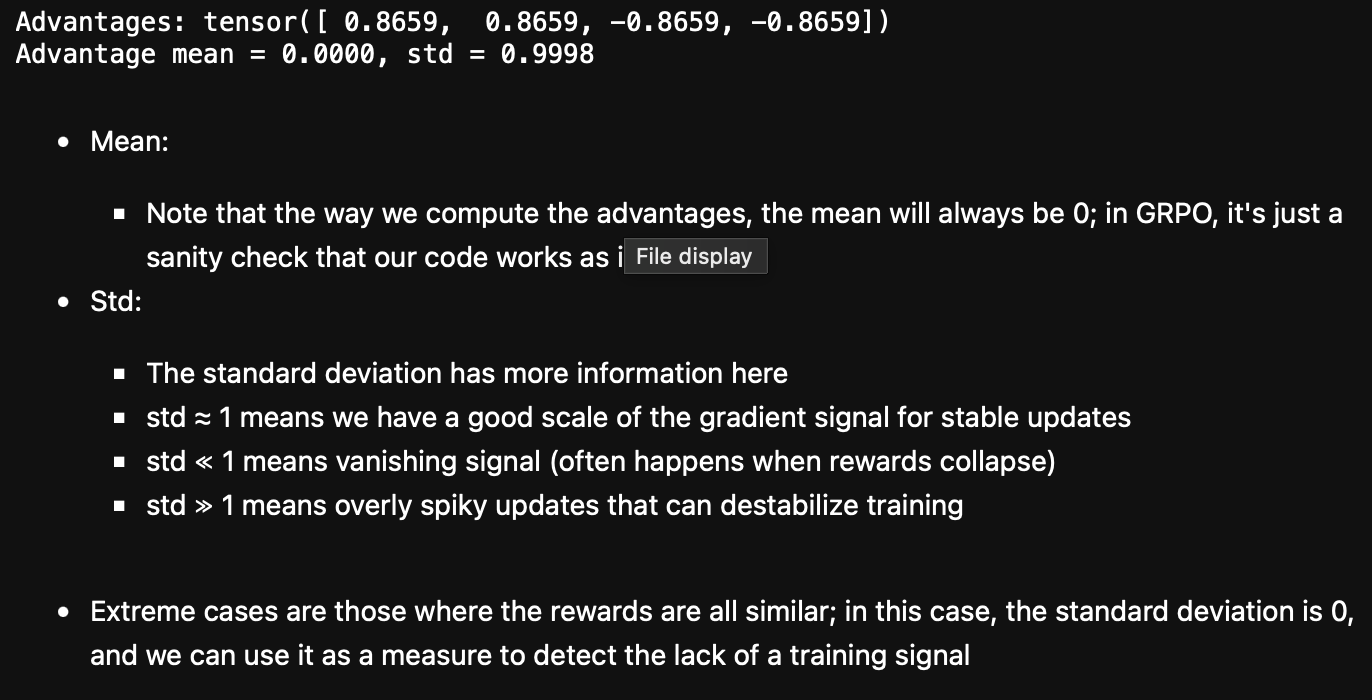


In [21]:
adv, adv_avg, adv_std = compute_advantage_stats([0.0, 0.0, 0.0, 0.0])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


In [22]:
adv, adv_avg, adv_std = compute_advantage_stats([1.0, 1.0, 1.0, 1.0])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


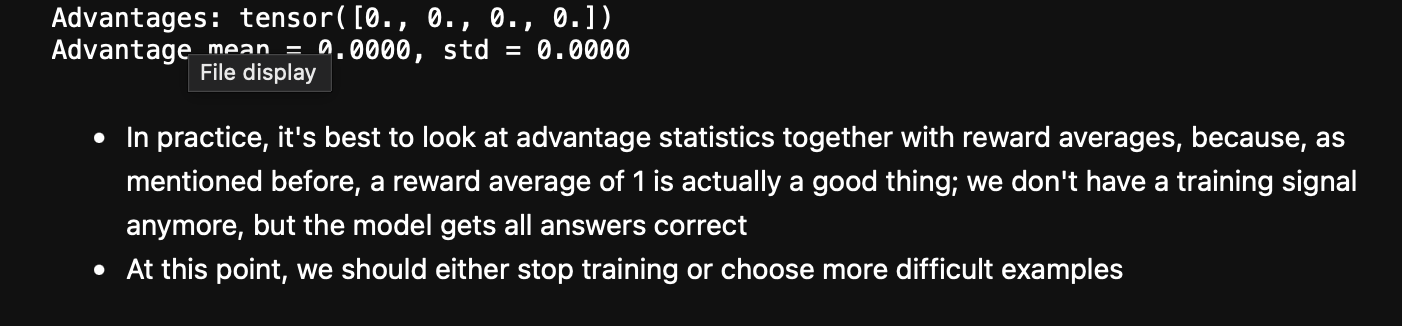


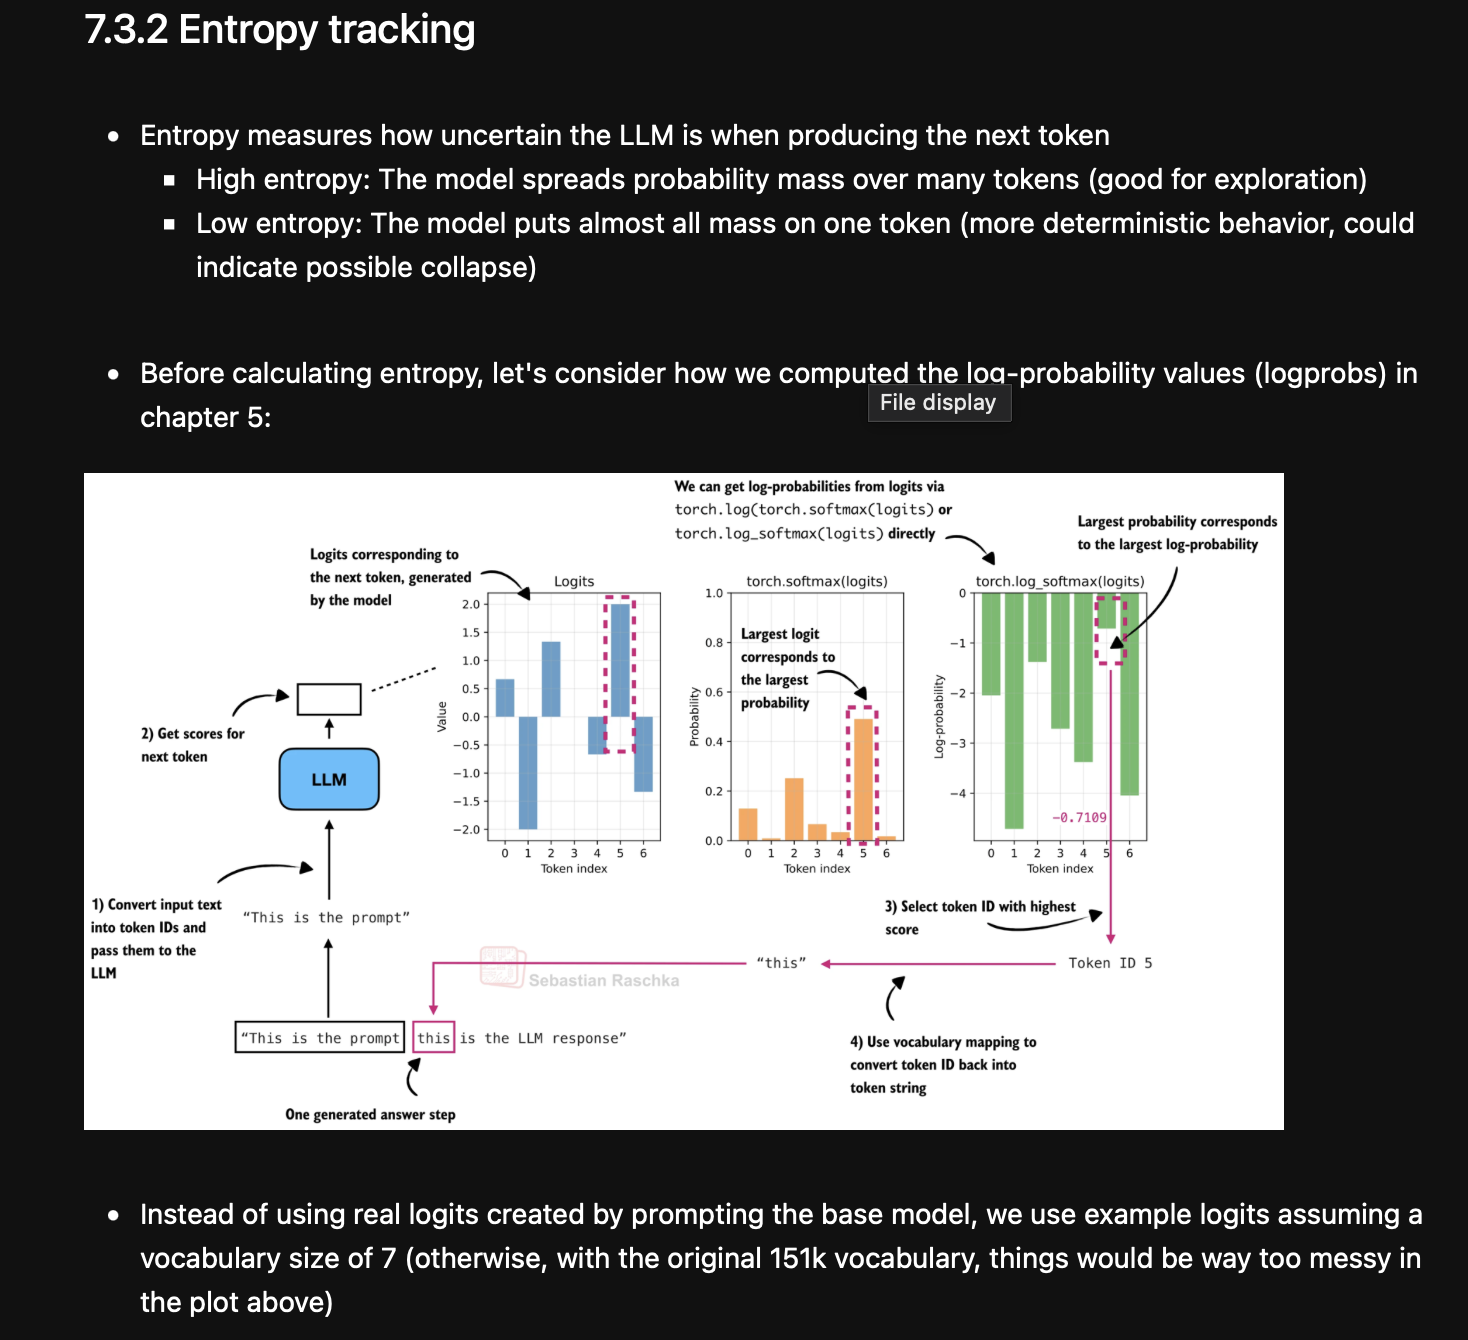


In [23]:
# Toy logits
logits = torch.tensor([0.6667, -2.0000, 1.3333, -0.0000, -0.6667, 2.0000, -1.3333])

In [24]:
# The code below implements the calculation from the previous figure:

logprobs = torch.log_softmax(logits, dim=-1)
print("All token logprobs:", logprobs)

# Index of the selected token
selected_token = torch.argmax(logprobs)

selected = logprobs[selected_token]
print("Selected token ID:", selected_token)
print("Selected token logprob:", selected)

All token logprobs: tensor([-2.0442, -4.7109, -1.3776, -2.7109, -3.3776, -0.7109, -4.0442])
Selected token ID: tensor(5)
Selected token logprob: tensor(-0.7109)
